In [1]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

In [11]:
articles = pl.read_csv('/home/nico/nico_mle/data/raw/articles.csv')
customers = pl.read_csv('/home/nico/nico_mle/data/raw/customers.csv')
transactions = pl.scan_csv('/home/nico/nico_mle/data/raw/transactions_train.csv')  # lazy

In [12]:
print('articles:    ', articles.shape)
print('customers:   ', customers.shape)
print('transactions:', transactions.collect().shape)  # triggers read

articles:     (105542, 25)
customers:    (1371980, 7)
transactions: (31788324, 5)


In [5]:
transactions.head(3).collect()

t_dat,customer_id,article_id,price,sales_channel_id
str,str,i64,f64,i64
"""2018-09-20""","""000058a12d5b43e67d225668fa1f8d…",663713001,0.050831,2
"""2018-09-20""","""000058a12d5b43e67d225668fa1f8d…",541518023,0.030492,2
"""2018-09-20""","""00007d2de826758b65a93dd24ce629…",505221004,0.015237,2


In [7]:
transactions.group_by("customer_id").agg(pl.len().alias("count")).sort("count", descending=True).collect() 

customer_id,count
str,u32
"""be1981ab818cf4ef6765b2ecaea7a2…",1895
"""b4db5e5259234574edfff958e170fe…",1441
"""49beaacac0c7801c2ce2d189efe525…",1364
"""a65f77281a528bf5c1e9f270141d60…",1361
"""cd04ec2726dd58a8c753e0d6423e57…",1237
…,…
"""1bb8c10e1558c5cce76584d1f71bd4…",1
"""be737925db2acb840a74d741636460…",1
"""966fa3086f7d31dec2677e2676e009…",1


In [13]:
activity = (                                                                                                     
      transactions                                                                                           
      .group_by("customer_id")                          
      .agg(pl.len().alias("count"))                                                                        
      .with_columns(
          pl.when(pl.col("count") > 500)                                                                     
          .then(pl.lit(1))
          .otherwise(pl.lit(0))                                                                              
          .alias("high_activity_flag"),
          pl.when(pl.col("count") < 5)                                                                     
          .then(pl.lit(1))
          .otherwise(pl.lit(0))                                                                              
          .alias("low_activity_flag")
      )                                                                                                    
      .sort("count", descending=True)
      .collect()                                                                                             
  )

In [26]:
activity.head(5)

customer_id,count,high_activity_flag,low_activity_flag
str,u32,i32,i32
"""be1981ab818cf4ef6765b2ecaea7a2…",1895,1,0
"""b4db5e5259234574edfff958e170fe…",1441,1,0
"""49beaacac0c7801c2ce2d189efe525…",1364,1,0
"""a65f77281a528bf5c1e9f270141d60…",1361,1,0
"""cd04ec2726dd58a8c753e0d6423e57…",1237,1,0


In [19]:
activity.group_by("high_activity_flag", "low_activity_flag").agg(pl.len().alias("Customers"))                                             

high_activity_flag,low_activity_flag,Customers
i32,i32,u32
1,0,474
0,1,436723
0,0,925084


In [14]:
item_activity = (                                                                                                     
      transactions                                                                                           
      .group_by("article_id")                          
      .agg(pl.len().alias("count"))                                                                        
      .with_columns(
          pl.when(pl.col("count") < 5)                                                                     
          .then(pl.lit(1))
          .otherwise(pl.lit(0))                                                                              
          .alias("low_activity_item")
      )                                                                                                    
      .sort("count", descending=True)
      .collect()                                                                                             
  )

In [20]:
activity.group_by("high_activity_flag", "low_activity_flag").agg(pl.col('count').sum().alias("total_transactions"))  

high_activity_flag,low_activity_flag,total_transactions
i32,i32,u32
0,0,30480760
1,0,305782
0,1,1001782


In [15]:
transactions_filtered = activity.filter((pl.col('high_activity_flag')) == 0 & (pl.col('low_activity_flag') == 0))

In [28]:
transactions_filtered.select([pl.col('customer_id').n_unique().alias('Unique customers'),
                              pl.col('count').sum().alias('total_transacionts')])

Unique customers,total_transacionts
u32,u32
1361807,31482542


In [29]:
customers.head(5)

customer_id,FN,Active,club_member_status,fashion_news_frequency,age,postal_code
str,f64,f64,str,str,i64,str
"""00000dbacae5abe5e23885899a1fa4…",null,null,"""ACTIVE""","""NONE""",49,"""52043ee2162cf5aa7ee79974281641…"
"""0000423b00ade91418cceaf3b26c6a…",null,null,"""ACTIVE""","""NONE""",25,"""2973abc54daa8a5f8ccfe9362140c6…"
"""000058a12d5b43e67d225668fa1f8d…",null,null,"""ACTIVE""","""NONE""",24,"""64f17e6a330a85798e4998f62d0930…"
"""00005ca1c9ed5f5146b52ac8639a40…",null,null,"""ACTIVE""","""NONE""",54,"""5d36574f52495e81f019b680c843c4…"
"""00006413d8573cd20ed7128e53b7b1…",1.0,1.0,"""ACTIVE""","""Regularly""",52,"""25fa5ddee9aac01b35208d01736e57…"


In [16]:
result = transactions_filtered.join(                                                                       
      customers.select(["customer_id", "FN", "Active", "club_member_status", "age"]),                                              
      on="customer_id",                                                                                    
      how="left"                                                                                             
  )

customer_id,count,high_activity_flag,low_activity_flag,FN,Active,club_member_status,age
str,u32,i32,i32,f64,f64,str,i64
"""55f65c7851a59ed348804d68b07d9e…",500,0,0,null,null,null,26
"""8244ee91f661730e4b0d94f404178b…",500,0,0,1.0,1.0,"""ACTIVE""",56
"""f5f98325ed8a2d75fc405e85efcdc0…",500,0,0,1.0,1.0,"""ACTIVE""",23
"""29f04ae4baf6eecf3d0da4e021a762…",500,0,0,null,null,"""ACTIVE""",28
"""df81358cb80f0faca7aa9e0e022b9b…",499,0,0,null,null,"""ACTIVE""",44


In [33]:
result.select([pl.col(c).is_null().sum().alias(c) for c in result.columns])                                

customer_id,count,high_activity_flag,low_activity_flag,FN,Active,club_member_status,age
u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,888736,901193,6054,15761


In [43]:
result.with_columns(
          pl.when(pl.col("age").is_null())                                                                     
          .then(pl.lit(1))
          .otherwise(pl.lit(0)).alias('age_null')).group_by("age_null").agg(pl.col("count").mean().alias("count_mean"))  

age_null,count_mean
i32,f64
0,23.284705
1,8.899055


In [45]:
result.filter(pl.col('count') == 9)["age"].mean()

36.27896165318572

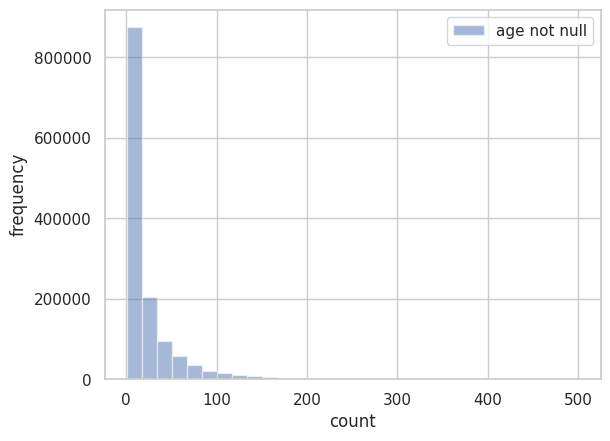

In [49]:
import matplotlib.pyplot as plt                                                                            
                                                                                                             
null_age = result.filter(pl.col("age").is_null())["count"].to_list()                                       
not_null_age = result.filter(pl.col("age").is_not_null())["count"].to_list()                               
                                                                                                                                                        
plt.hist(not_null_age, bins=30, alpha=0.5, label="age not null")
plt.xlabel("count")                                                                                        
plt.ylabel("frequency")                                                                                    
plt.legend()                                                                                             
plt.show()

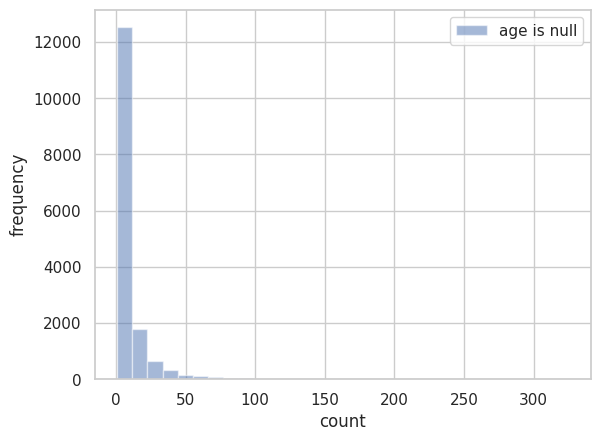

In [48]:
import matplotlib.pyplot as plt                                                                            
                                                                                                             
null_age = result.filter(pl.col("age").is_null())["count"].to_list()                                       
not_null_age = result.filter(pl.col("age").is_not_null())["count"].to_list()                               
                                                                                                           
plt.hist(null_age, bins=30, alpha=0.5, label="age is null")                                                
plt.xlabel("count")                                                                                        
plt.ylabel("frequency")                                                                                    
plt.legend()                                                                                             
plt.show()

In [17]:
final_results = result.filter(pl.col("age").is_not_null())                                                                 

In [52]:
"""I decided to filter out where age is null. 
Two reasons: 
-They only represent a small amount of customers out of the total (15k out of 1.3M)
-The count of transactions distribution is the same as the ones that have age.

I'm also dropping FN and Active fields, too many nulls. I'm just using club_member_status.
"""

"I decided to filter out where age is null. \nTwo reasons: \n-They only represent a small amount of customers out of the total (15k out of 1.3M)\n-The count of transactions distribution is the same as the ones that have age.\n\nI'm also dropping FN and Active fields, too many nulls. I'm just using club_member_status.\n"

In [18]:
transactions_filtered = (
      transactions                                                                                           
      .join(                                                                                               
          activity.lazy().filter(                                                                          
              (pl.col("high_activity_flag") == 0) & (pl.col("low_activity_flag") == 0)                     
          ).select("customer_id"),                                                                           
          on="customer_id",
          how="inner"                                                                                        
      ).join(item_activity.lazy().filter(pl.col("low_activity_item") == 0).select("article_id"), on = "article_id", how = "inner")
      .collect()                                                                                           
  )     

In [20]:
len(transactions_filtered)

30454020

In [18]:
len(transactions_filtered)

30480760

In [56]:
transactions_filtered.head(5)

t_dat,customer_id,article_id,price,sales_channel_id
str,str,i64,f64,i64
"""2018-09-20""","""000058a12d5b43e67d225668fa1f8d…",663713001,0.050831,2
"""2018-09-20""","""000058a12d5b43e67d225668fa1f8d…",541518023,0.030492,2
"""2018-09-20""","""00007d2de826758b65a93dd24ce629…",505221004,0.015237,2
"""2018-09-20""","""00007d2de826758b65a93dd24ce629…",685687003,0.016932,2
"""2018-09-20""","""00007d2de826758b65a93dd24ce629…",685687004,0.016932,2


In [59]:
transactions_filtered.group_by('customer_id', 'article_id').len().head(5)

customer_id,article_id,len
str,i64,u32
"""899526697ad0bd16c1ad3857ebe52b…",823118002,2
"""79b3767472cee3deecf0e95f4315d5…",850259002,1
"""52cab908f03d83a114ec435b863c42…",669091001,1
"""5fa2446b404763cc74487c8d4175e5…",771602002,1
"""a108f6a1d2e52e8ea00e868e6e547f…",720504002,1


In [19]:
agg = (                                                                                                                                                                                                                                                  
      transactions_filtered                                                                                                                                                                                                                                
      .group_by(["customer_id", "article_id"])                                                                                                                                                                                                             
      .agg(pl.len().alias("purchase_count"))                                                                                                                                                                                                               
  )

In [20]:
from scipy.sparse import csr_matrix                                                                                                                                                                                                                      
                                                                                                                                                                                                                                                         
agg_pd = agg.to_pandas()                                                                                                                                                                                                                                 
agg_pd["customer_id"] = agg_pd["customer_id"].astype("category")                                                                                                                                                                                       
agg_pd["article_id"]  = agg_pd["article_id"].astype("category") 
                                                                                                                                                                                                                                                         
row  = agg_pd["customer_id"].cat.codes.to_numpy()
col  = agg_pd["article_id"].cat.codes.to_numpy()                                                                                                                                                                                                         
data = agg_pd["purchase_count"].to_numpy(dtype="int32")                                                                                                                                                                                                
                                                                                                                                                                                                                                                         
customer_idx = agg_pd["customer_id"].cat.categories  # int → customer_id                                                                                                                                                                                 
article_idx  = agg_pd["article_id"].cat.categories   # int → article_id                                                                                                                                                                                  
                                                                                                                                                                                                                                                         
n_users, n_items = customer_idx.size, article_idx.size                                                                                                                                                                                                   
user_item = csr_matrix((data, (row, col)), shape=(n_users, n_items), dtype="int32")

In [23]:
import scipy.sparse as sp
import numpy as np

sp.save_npz("../data/processed/user_item.npz", user_item)
np.save("../data/processed/customer_idx.npy", customer_idx.to_numpy())
np.save("../data/processed/article_idx.npy", article_idx.to_numpy())

In [23]:
sparsity = (1 - user_item.nnz / (n_users * n_items)) * 100                                                                                                                                                                                             
print(f"Shape    : {user_item.shape}")                                                                                                                                                                                                                   
print(f"Non-zeros: {user_item.nnz:,}")                                                                                                                                                                                                                   
print(f"Sparsity : {sparsity:.4f}%")

Shape    : (925084, 91875)
Non-zeros: 26,128,552
Sparsity : 99.9693%


In [24]:
import numpy as np                                                                                                                                                                                                                                       
                                                                                                                                                                                                                                                         
top_items     = np.asarray(user_item.sum(axis=0)).flatten().argsort()[-10:][::-1]                                                                                                                                                                        
top_customers = np.asarray(user_item.sum(axis=1)).flatten().argsort()[-10:][::-1]                                                                                                                                                                        
                                                                                                                                                                                                                                                         
preview = user_item[top_customers, :][:, top_items].toarray()                                                                                                                                                                                            
                                                                                                                                                                                                                                                       
pd.DataFrame(                                                                                                                                                                                                                                            
    preview,                                                                                                                                                                                                                                             
    index=[str(customer_idx[i])[:10] + "…" for i in top_customers],
    columns=[str(article_idx[i]) for i in top_items]                                                                                                                                                                                                     
)

,706016001,706016002,372860001,610776002,759871002,464297007,372860002,610776001,399223001,156231001
8244ee91f6…,0,0,0,0,0,0,0,0,0,0
29f04ae4ba…,0,0,0,0,0,0,0,0,0,0
f5f98325ed…,2,0,0,0,0,0,0,0,0,0
eae74dc3e7…,0,0,0,0,0,0,0,0,0,0
df81358cb8…,0,0,0,0,0,0,0,0,0,0
f49a759af7…,2,0,0,1,0,0,0,0,0,0
5e4cee0f52…,0,0,0,0,1,0,0,0,0,0
5bec5aabad…,0,0,0,0,2,0,0,0,0,0
443cfdf72e…,0,0,0,0,3,1,0,0,0,0
b63620c6c9…,1,0,0,0,0,0,0,2,1,0
